<img src="https://drive.google.com/uc?export=view&id=1Y-EIpLOigI9ycCOZRrRSFzAfuN9cxhqT" alt="Hobot Academy" width="300" height="300">

<h1 align="center"><font size="14">Hands-On Machine Learning</font></h1>
<h3 align="center"><font size="7">Session11: Logistic Regression with scikit-learn</font></h3>
<h3 align="center">Zahra Amini</h3>

# Step1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, plot_confusion_matrix

# Step2: Read Data

In [2]:
df= pd.read_csv('Breast_Cancer.csv')

# Step3: Data Overview

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    int64  
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df.drop('Unnamed: 32', axis=1, inplace=True)

In [6]:
df.shape

(569, 32)

In [7]:
df.drop('id', axis=1, inplace=True)

In [8]:
df.shape

(569, 31)

### Step4: Data Analysis

In [9]:
df['diagnosis'].value_counts()

0    357
1    212
Name: diagnosis, dtype: int64

<AxesSubplot:xlabel='diagnosis', ylabel='count'>

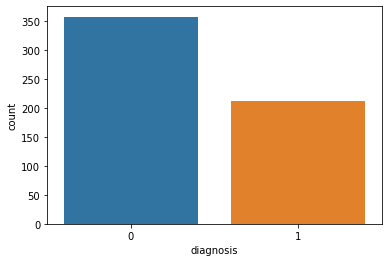

In [10]:
sns.countplot(data=df, x='diagnosis')

In [11]:
df.corr()[['diagnosis']].sort_values(by='diagnosis', ascending=False).T

,diagnosis,concave points_worst,perimeter_worst,concave points_mean,radius_worst,perimeter_mean,area_worst,radius_mean,area_mean,concavity_mean,...,smoothness_mean,symmetry_mean,fractal_dimension_worst,compactness_se,concavity_se,fractal_dimension_se,symmetry_se,texture_se,fractal_dimension_mean,smoothness_se
diagnosis,1.0,0.793566,0.782914,0.776614,0.776454,0.742636,0.733825,0.730029,0.708984,0.69636,...,0.35856,0.330499,0.323872,0.292999,0.25373,0.077972,-0.006522,-0.008303,-0.012838,-0.067016


<AxesSubplot:xlabel='concave points_worst', ylabel='diagnosis'>

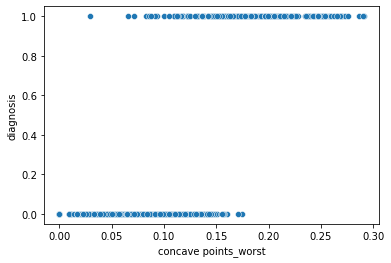

In [12]:
sns.scatterplot(data=df, x='concave points_worst', y='diagnosis')

### Step5: Determine the Features & Target Variable

In [13]:
X = df.drop('diagnosis', axis=1)

y=df['diagnosis']

### Step6: Split the Dataset to Tain & Test set

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    random_state=42)

### Step7: Scaling the Features

In [15]:
scaler = StandardScaler()

In [16]:
scaler.fit(X_train)

StandardScaler()

In [17]:
s_X_train = scaler.transform(X_train)

s_X_test = scaler.transform(X_test)

### Step8: Train the Model

In [18]:
log = LogisticRegression()

In [19]:
log.fit(s_X_train, y_train)

LogisticRegression()

In [20]:
log.coef_

array([[ 0.36151014,  0.36590894,  0.31610122,  0.41880063,  0.18212827,
        -0.62679803,  0.74987144,  1.11026184, -0.21782944, -0.13788028,
         1.24254311, -0.15541981,  0.60518674,  0.87138493,  0.17738092,
        -0.59728543,  0.08110875,  0.47494075, -0.50330967, -0.69838981,
         0.8138174 ,  1.2879328 ,  0.53402497,  0.78196751,  0.50440415,
        -0.11569862,  0.97693569,  0.79835894,  1.19944887,  0.10073636]])

### Step9: Predicting Test Data

In [21]:
y_pred = log.predict(s_X_test)

### Step10: Evaluating the Model

In [22]:
accuracy_score(y_test, y_pred)

0.9824561403508771

In [23]:
y_test.value_counts()

0    108
1     63
Name: diagnosis, dtype: int64

In [24]:
confusion_matrix(y_test, y_pred)

array([[106,   2],
       [  1,  62]], dtype=int64)

C:\Users\amini\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


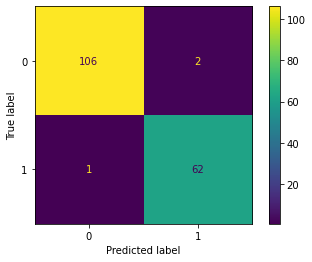

In [25]:
plot_confusion_matrix(log, s_X_test, y_test)

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       108
           1       0.97      0.98      0.98        63

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



# Finished!